In [1]:
import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Planck2013 import Planck2013

TypeError: 'Quantity' object is not callable

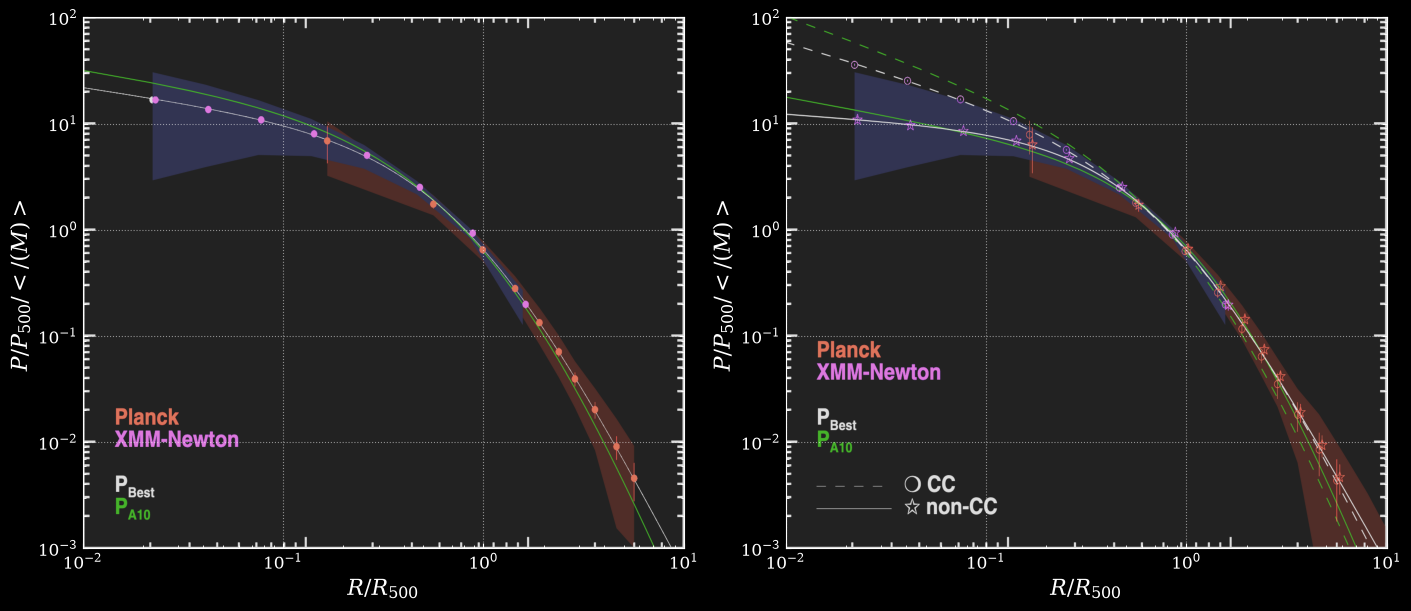

In [4]:
importlib.reload(Planck2013)
fig, axs = Planck2013.Fig4().full()

from Models import HaloModels, Profiles
importlib.reload(HaloModels); importlib.reload(Profiles)

r = np.geomspace(1e-3, 1e1, 50)
z, logM500c = 0.2, np.log10(2e13)
hmod = HaloModels.pyccl_model(Profiles.Planck2013().info)
x = r*u.Mpc/hmod.rdel('500c')(z, logM500c)

P_del = lambda P13: (P13.Pressure(r*0.7**2, z, logM500c)()/P13.P500(z, logM500c)())[:, 0, 0]

P13 = lambda **spefs: Profiles.Planck2013(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
axs[0].scatter(x, P_del(P13(cluster='All',fixedp='1')), marker='o', alpha=0.5, c='w', label='P13 all')
axs[1].scatter(x, P_del(P13(cluster='cool')), marker='o', alpha=0.5, c='w', label='P13 cool')   
axs[1].scatter(x, P_del(P13(cluster='noncool')), marker='x', alpha=0.5, c='w', label='P13 noncool')                                                                            

A10 = lambda **spefs: Profiles.Arnaud2010(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
axs[0].scatter(x, P_del(A10()), marker='o', alpha=0.5, c='g', label='A10')
axs[1].scatter(x, P_del(A10()), marker='o', alpha=0.5, c='g', label='A10')                                                     

axs[0].legend(); axs[1].legend()
plt.show()

AttributeError: 'Planck2013' object has no attribute 'P_del'

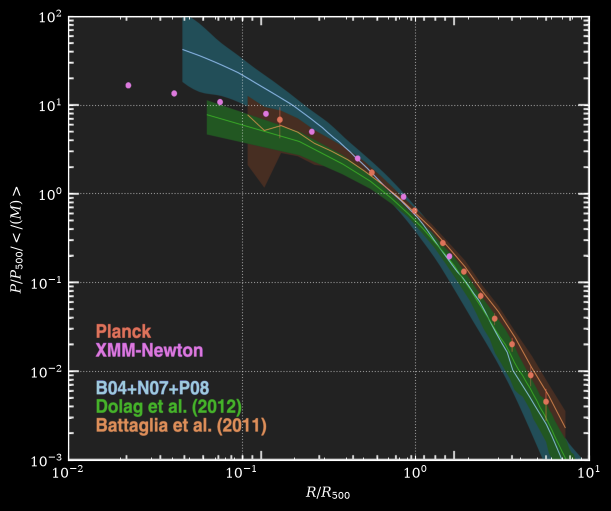

In [6]:
importlib.reload(Planck2013)
fig, ax = Planck2013.Fig6().full()

from Models import HaloModels, Profiles
importlib.reload(HaloModels); importlib.reload(Profiles)

rs = np.geomspace(1e-3, 1e1, 50)
z, logMh = 1, np.log10(5e14)

hmod = HaloModels.pyccl_model(Profiles.Planck2013().info)
P13 = Profiles.Planck2013(cluster='All', fixedp='3',rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
ax.scatter(rs/hmod.rdel('500c')(z, logMh), P13.P_del(rs, z, logMh)()[:, 0, 0], marker='x', alpha=0.8, c='red', label='Planck')          

# logM200c = HaloModels.pyccl_model(Profiles.Battaglia2011().info, MassDef='500c', Concentration='Constant').logM_conv(z, logMh, '200c', c0=1)
# hmod200c = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
# Battaglia11 = Profiles.Battaglia2011(rhoc=hmod200c.rhoc, r200c=hmod200c.rdel('200c'))
# ax.scatter(rs/hmod.rdel('500c')(z, logMh), P13.pres(rs, z, logMh)()[:, 0, 0]/, marker='X', alpha=0.8, c='lime', label='B11')

ax.legend()
plt.show()